<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/CNN_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full CNN Architecture for Image Classification

## 1. The Complete CNN Pipeline

A standard CNN classifier follows:

Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → Fully Connected

Each component has a precise role:

- **Convolution:** extracts local spatial features.
- **ReLU:** introduces non-linearity.
- **Pooling:** reduces spatial resolution.
- **Flatten:** converts feature maps to vectors.
- **Fully Connected:** performs classification.

This mirrors ANN, but with spatial structure built in.

## 2. Convolution as a Structured Linear Operation

Recall ANN:

$$
y = Wx + b
$$

Convolution is also linear in the input.

However:

- Weights are arranged in small kernels.
- The same kernel is reused across space.
- Connections are local (not global).

Therefore:

Convolution = Linear transformation with structured sparsity + weight sharing.

This is why CNN is more parameter efficient than ANN on images.

## 3. Tensor Shape Flow (Explicit Derivation)

We use NCHW format:

$$
x \in \mathbb{R}^{N \times C \times H \times W}
$$

For a convolution layer:

- Input channels = $C_{in}$
- Output channels = $C_{out}$
- Kernel size = $K$
- Stride = $S$
- Padding = $P$

Output spatial dimensions:

$$
H_{out} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1
$$

$$
W_{out} = \left\lfloor \frac{W + 2P - K}{S} \right\rfloor + 1
$$

Output tensor:

$$
\mathbb{R}^{N \times C_{out} \times H_{out} \times W_{out}}
$$

Pooling (2×2, stride 2) halves H and W.

## 4. Parameter Count Comparison

For Conv2D:

$$
\#params = C_{out}(C_{in}K^2 + 1)
$$

For Fully Connected:

$$
\#params = d_{out}(d_{in} + 1)
$$

Notice:

Convolution parameter count does NOT depend on image height or width.

Fully connected layers scale directly with input dimension.

This is the key source of CNN efficiency.

Input: torch.Size([4, 3, 32, 32])
After conv1: torch.Size([4, 16, 32, 32])
After ReLU1: torch.Size([4, 16, 32, 32])
After pool1: torch.Size([4, 16, 16, 16])
After conv2: torch.Size([4, 32, 16, 16])
After ReLU2: torch.Size([4, 32, 16, 16])
After pool2: torch.Size([4, 32, 8, 8])
After flatten: torch.Size([4, 2048])
After fc1: torch.Size([4, 64])
After ReLU3: torch.Size([4, 64])
Logits: torch.Size([4, 10])

Total trainable params (SmallCNN): 136.87K
  conv1 params: 448
  conv2 params: 4.64K
  fc1 params  : 131.14K
  fc2 params  : 650

Total trainable params (naive ANN): 789.26K
  First Linear params: 786.69K
  Last Linear params : 2.57K


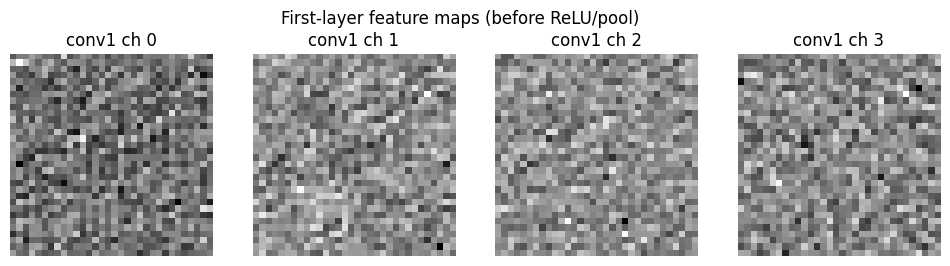

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Utility: parameter counting
# -----------------------------
def count_params(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def pretty_num(n: int) -> str:
    # small helper for readability
    if n >= 1_000_000:
        return f"{n/1_000_000:.2f}M"
    if n >= 1_000:
        return f"{n/1_000:.2f}K"
    return str(n)

# -----------------------------
# A small "full" CNN classifier
# Conv -> ReLU -> Pool -> Conv -> ReLU -> Pool -> Flatten -> FC
# Input assumed: (N, 3, 32, 32)
# -----------------------------
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1) # keeps H,W
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2) # halves H,W
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1) # keeps
        # After two pools: 32x32 -> 16x16 -> 8x8
        self.fc1   = nn.Linear(32*8*8, 64)
        self.fc2   = nn.Linear(64, num_classes)

    def forward(self, x):
        print("Input:", x.shape)

        x = self.conv1(x)
        print("After conv1:", x.shape)

        x = F.relu(x)
        print("After ReLU1:", x.shape)

        x = self.pool(x)
        print("After pool1:", x.shape)

        x = self.conv2(x)
        print("After conv2:", x.shape)

        x = F.relu(x)
        print("After ReLU2:", x.shape)

        x = self.pool(x)
        print("After pool2:", x.shape)

        x = torch.flatten(x, start_dim=1)  # flatten all except batch
        print("After flatten:", x.shape)

        x = self.fc1(x)
        print("After fc1:", x.shape)

        x = F.relu(x)
        print("After ReLU3:", x.shape)

        logits = self.fc2(x)
        print("Logits:", logits.shape)

        return logits

# -----------------------------
# Dummy forward pass
# -----------------------------
model = SmallCNN(num_classes=10)

dummy = torch.randn(4, 3, 32, 32)  # (N=4, C=3, H=32, W=32)
logits = model(dummy)

print("\nTotal trainable params (SmallCNN):", pretty_num(count_params(model)))
print("  conv1 params:", pretty_num(count_params(model.conv1)))
print("  conv2 params:", pretty_num(count_params(model.conv2)))
print("  fc1 params  :", pretty_num(count_params(model.fc1)))
print("  fc2 params  :", pretty_num(count_params(model.fc2)))

# -----------------------------
# Compare with a naive ANN that flattens the image first
# ANN: Flatten (3*32*32) -> 256 -> 10
# -----------------------------
ann = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*32*32, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

print("\nTotal trainable params (naive ANN):", pretty_num(count_params(ann)))
print("  First Linear params:", pretty_num(count_params(ann[1])))
print("  Last Linear params :", pretty_num(count_params(ann[3])))

# -----------------------------
# Visualization: feature maps after conv1
# We'll show first 4 channels of conv1 output for the first image in the batch.
# -----------------------------
with torch.no_grad():
    x = dummy[:1]  # take one image
    fm = model.conv1(x)  # (1, 16, 32, 32)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(fm[0, i].cpu(), cmap="gray")
    axes[i].set_title(f"conv1 ch {i}")
    axes[i].axis("off")
plt.suptitle("First-layer feature maps (before ReLU/pool)")
plt.show()

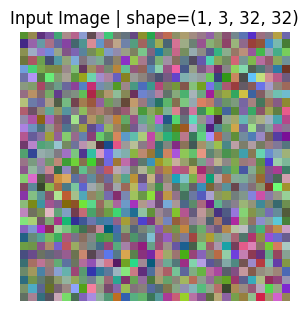

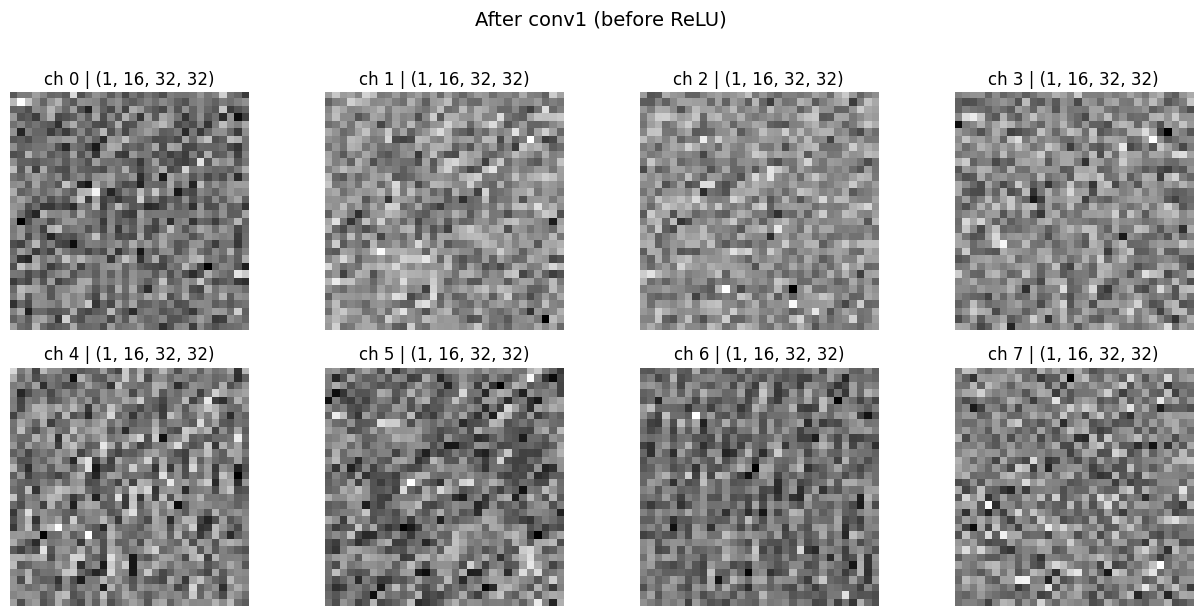

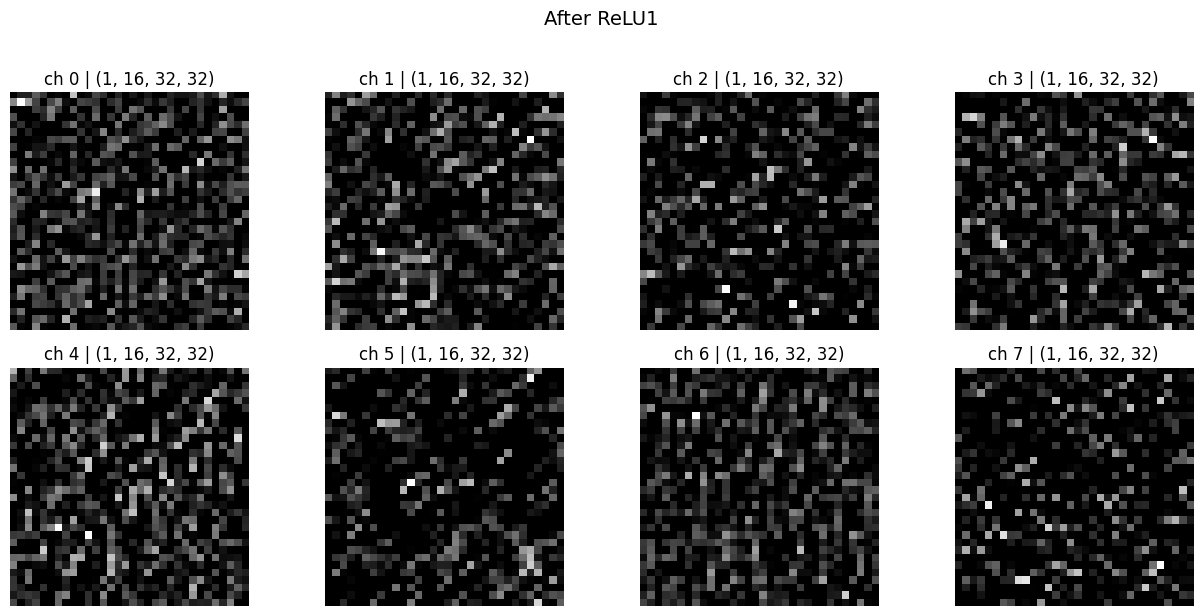

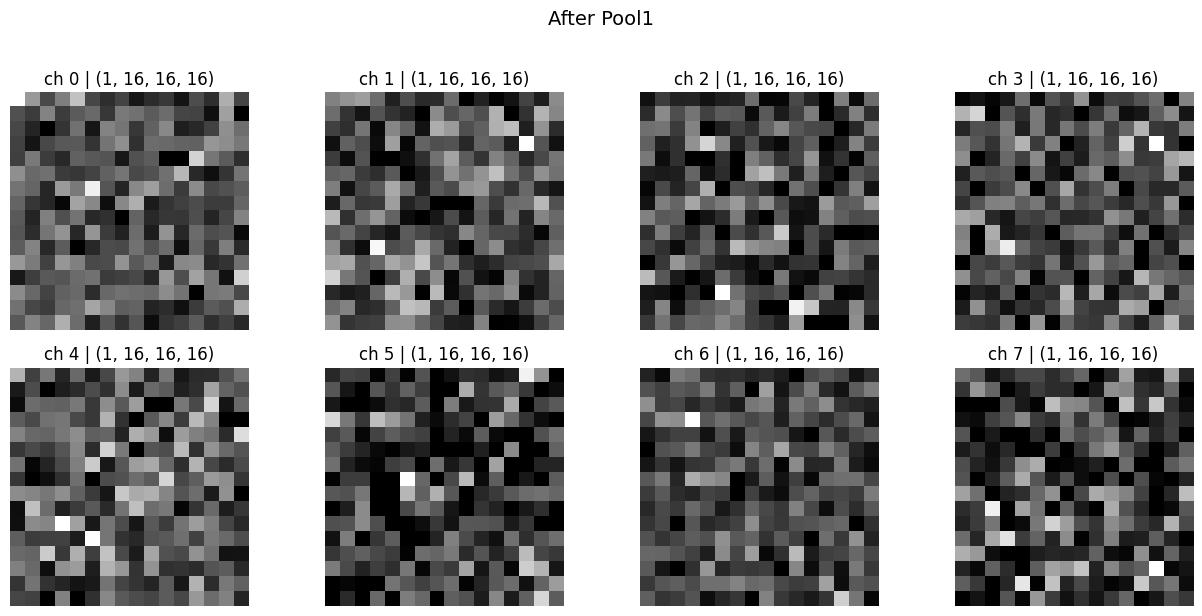

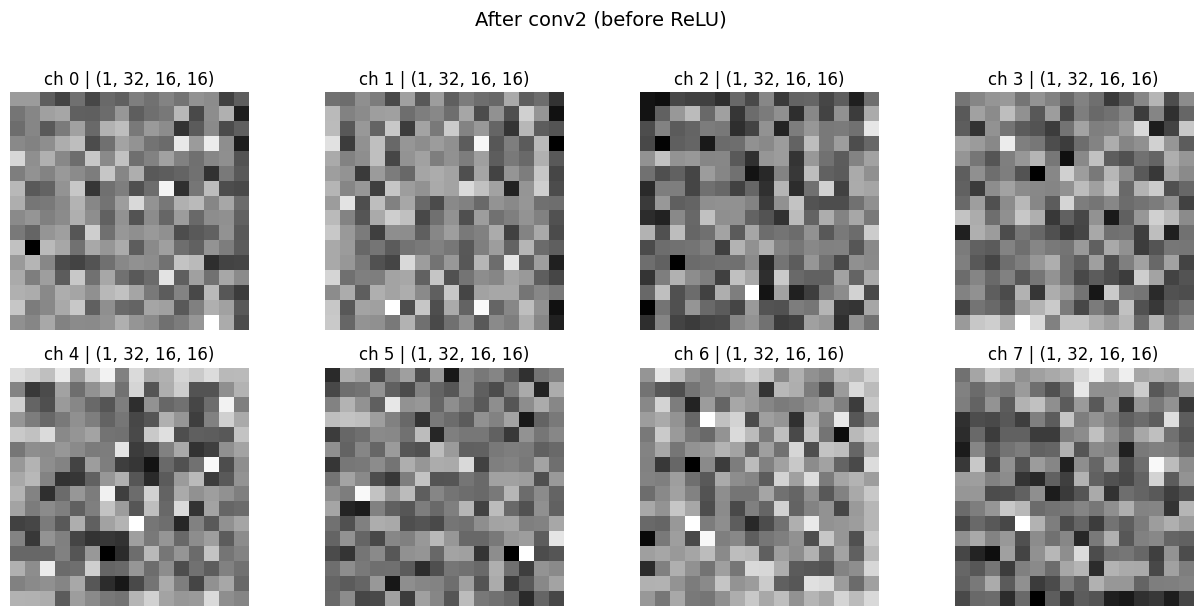

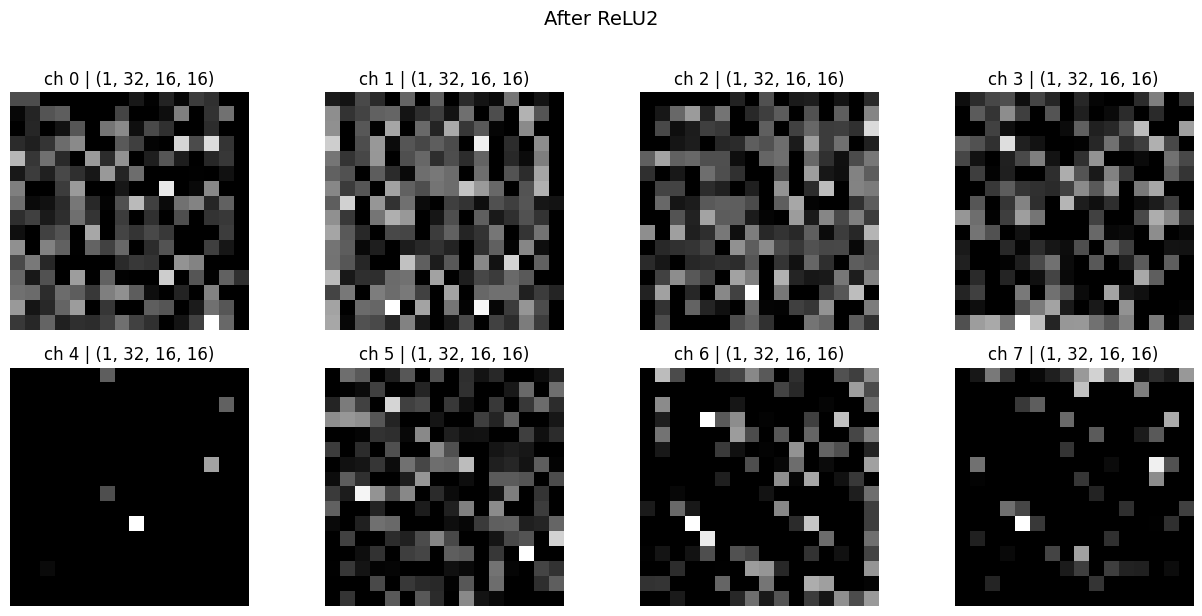

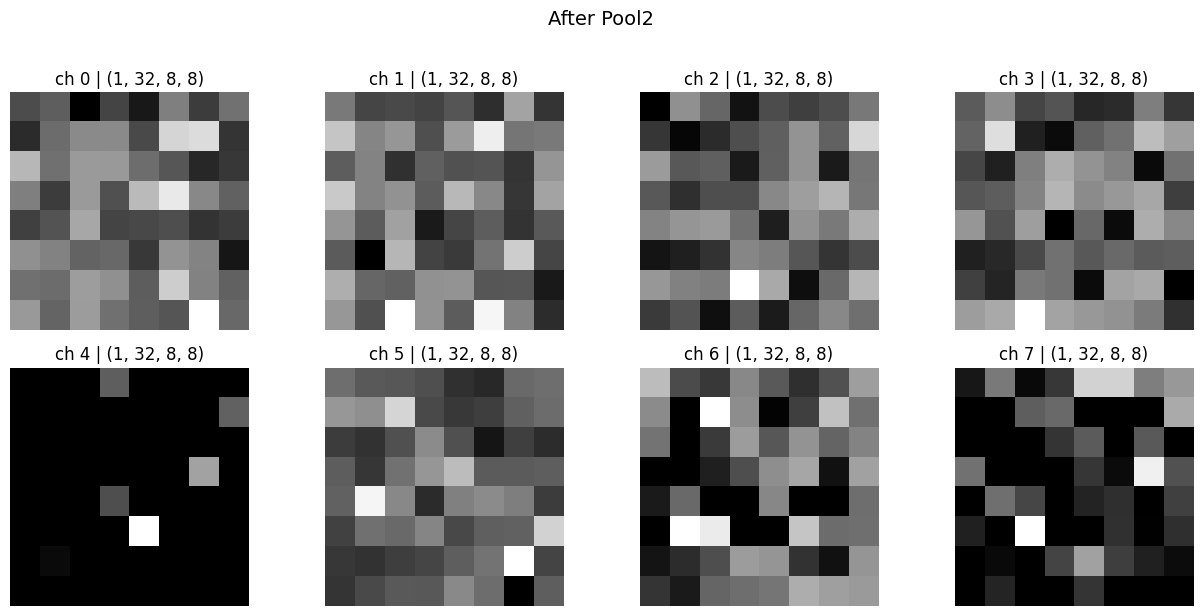

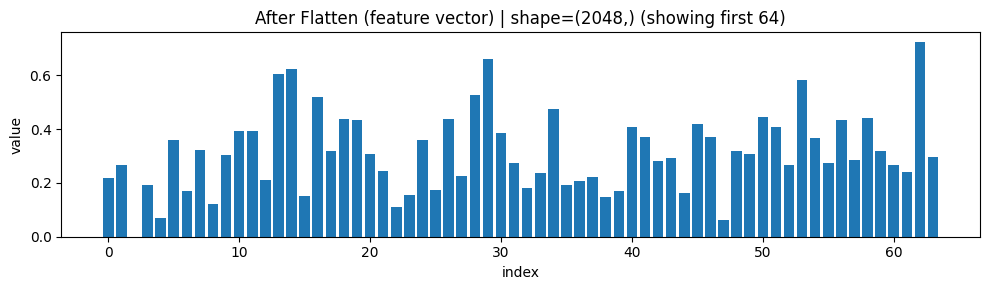

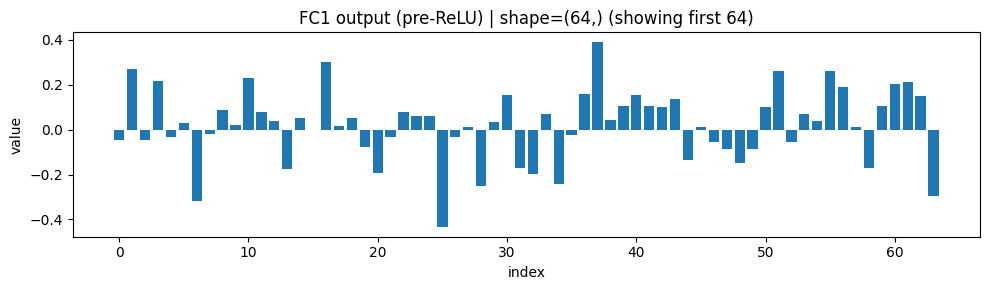

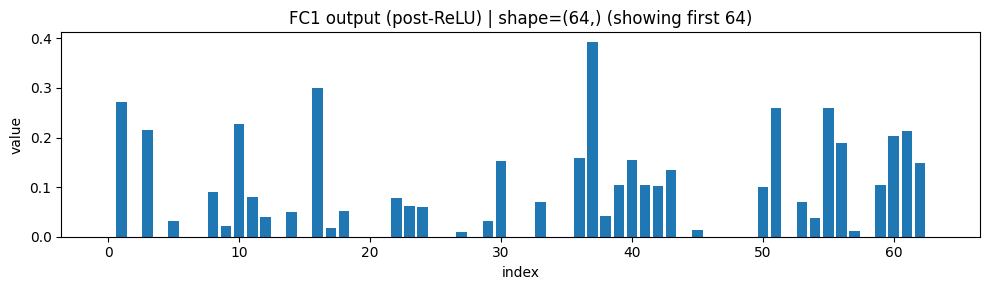

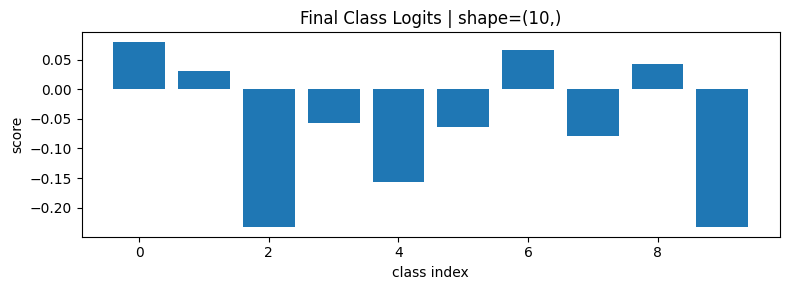

In [ ]:
# ------------------------------------------------------------
# Full-step VISUALIZATION for SmallCNN forward pass
# Covers: Input -> conv1 -> relu1 -> pool1 -> conv2 -> relu2 -> pool2
#         -> flatten -> fc1 (pre/post ReLU) -> logits
#
# Assumptions:
# 1) You already have `model = SmallCNN(...)` defined (from Section 1 code)
# 2) You already have `dummy` defined with shape (N, 3, 32, 32)
# ------------------------------------------------------------

import torch
import matplotlib.pyplot as plt

# ---------- helper plotting utilities ----------
def _to_cpu(x):
    return x.detach().cpu()

def show_rgb_image(x_nchw, title="Input (RGB)"):
    # x_nchw: (1,3,H,W)
    x = _to_cpu(x_nchw)[0]
    # normalize for visualization
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    rgb = x.permute(1, 2, 0)  # HWC
    plt.figure(figsize=(3.5, 3.5))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_channels_grid(feat_nchw, title, num_channels=8, cols=4, cmap="gray"):
    # feat_nchw: (1,C,H,W)
    feat = _to_cpu(feat_nchw)[0]  # (C,H,W)
    C = feat.shape[0]
    num = min(num_channels, C)
    rows = (num + cols - 1) // cols

    plt.figure(figsize=(3.2 * cols, 3.0 * rows))
    for i in range(num):
        ax = plt.subplot(rows, cols, i + 1)
        img = feat[i]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img, cmap=cmap)
        ax.set_title(f"ch {i} | {tuple(feat_nchw.shape)}")
        ax.axis("off")
    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

def show_vector_bar(vec_1d, title, max_bars=64):
    v = _to_cpu(vec_1d).flatten()
    n = min(max_bars, v.numel())
    v = v[:n]
    plt.figure(figsize=(10, 3))
    plt.bar(range(n), v.numpy())
    plt.title(f"{title} | shape={tuple(vec_1d.shape)} (showing first {n})")
    plt.xlabel("index")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

def show_logits_bar(logits_1d, title="Logits"):
    v = _to_cpu(logits_1d).flatten()
    plt.figure(figsize=(8, 3))
    plt.bar(range(v.numel()), v.numpy())
    plt.title(f"{title} | shape={tuple(logits_1d.shape)}")
    plt.xlabel("class index")
    plt.ylabel("score")
    plt.tight_layout()
    plt.show()

# ---------- capture activations step-by-step ----------
model.eval()

x0 = dummy[:1]  # take first image only for clear visualization

with torch.no_grad():
    acts = {}

    acts["input"] = x0

    z1 = model.conv1(x0);           acts["conv1"] = z1
    a1 = torch.relu(z1);            acts["relu1"] = a1
    p1 = model.pool(a1);            acts["pool1"] = p1

    z2 = model.conv2(p1);           acts["conv2"] = z2
    a2 = torch.relu(z2);            acts["relu2"] = a2
    p2 = model.pool(a2);            acts["pool2"] = p2

    flat = torch.flatten(p2, 1);    acts["flatten"] = flat

    fc1_pre = model.fc1(flat);      acts["fc1_pre"] = fc1_pre
    fc1_post = torch.relu(fc1_pre); acts["fc1_post"] = fc1_post

    logits = model.fc2(fc1_post);   acts["logits"] = logits

# ---------- Visualize each stage ----------
# 1) Input
show_rgb_image(acts["input"], title=f"Input Image | shape={tuple(acts['input'].shape)}")

# 2) conv1 / relu1 / pool1
show_channels_grid(acts["conv1"], title="After conv1 (before ReLU)", num_channels=8, cols=4)
show_channels_grid(acts["relu1"], title="After ReLU1", num_channels=8, cols=4)
show_channels_grid(acts["pool1"], title="After Pool1", num_channels=8, cols=4)

# 3) conv2 / relu2 / pool2
show_channels_grid(acts["conv2"], title="After conv2 (before ReLU)", num_channels=8, cols=4)
show_channels_grid(acts["relu2"], title="After ReLU2", num_channels=8, cols=4)
show_channels_grid(acts["pool2"], title="After Pool2", num_channels=8, cols=4)

# 4) Flatten (vector) and FC layers
show_vector_bar(acts["flatten"][0], title="After Flatten (feature vector)", max_bars=64)
show_vector_bar(acts["fc1_pre"][0], title="FC1 output (pre-ReLU)", max_bars=64)
show_vector_bar(acts["fc1_post"][0], title="FC1 output (post-ReLU)", max_bars=64)

# 5) Logits
show_logits_bar(acts["logits"][0], title="Final Class Logits")

## Concept-Check Questions

1) If input is (N, 3, 32, 32) and conv1 is (out=16, K=3, S=1, P=1), what is the output shape?

2) After MaxPool2d(2,2), what happens to H and W?

3) Why does convolution parameter count NOT depend on H and W?

4) Which layer in this CNN likely has the highest parameter count? Why?

5) If stride=2 in first conv (K=3, P=1), what happens to spatial size?

# Training a CNN

## 1. Loss Function for Classification

For multi-class classification, we use **Cross-Entropy Loss**.

Given logits:

$$
z \in \mathbb{R}^{N \times C}
$$

Softmax converts logits to probabilities:

$$
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

Cross-entropy loss:

$$
\mathcal{L} = - \sum_{i=1}^{C} y_i \log(p_i)
$$

In PyTorch:

- `nn.CrossEntropyLoss()` combines:
    - LogSoftmax
    - Negative Log Likelihood

Important:
We feed raw logits (NOT softmax outputs).

## 2. Backpropagation Reminder

CNN training uses the same principle as ANN.

Forward pass:

$$
x \rightarrow f(x) \rightarrow \mathcal{L}
$$

Backward pass:

$$
\frac{\partial \mathcal{L}}{\partial W}
$$

Key idea:

Convolution is still a linear operation.

Therefore:

Gradients flow through CNN exactly like ANN, but respecting weight sharing.

Weight sharing means:
Each kernel update accumulates gradients from all spatial positions.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Reuse SmallCNN from Section 1
model = SmallCNN(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dummy dataset
batch_size = 8
inputs = torch.randn(batch_size, 3, 32, 32)
targets = torch.randint(0, 10, (batch_size,))

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)

# ---- Single Training Step ----
model.train()

outputs = model(inputs)
print("Logits shape:", outputs.shape)

loss = criterion(outputs, targets)
print("Loss:", loss.item())

optimizer.zero_grad()
loss.backward()

# ---- Gradient Inspection ----
print("\nGradient Magnitudes:")

for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name:15s} | grad mean: {param.grad.abs().mean():.6f}")

optimizer.step()

Input shape: torch.Size([8, 3, 32, 32])
Target shape: torch.Size([8])
Input: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After ReLU1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After ReLU2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])
After flatten: torch.Size([8, 2048])
After fc1: torch.Size([8, 64])
After ReLU3: torch.Size([8, 64])
Logits: torch.Size([8, 10])
Logits shape: torch.Size([8, 10])
Loss: 2.3421895503997803

Gradient Magnitudes:
conv1.weight    | grad mean: 0.006977
conv1.bias      | grad mean: 0.007493
conv2.weight    | grad mean: 0.008406
conv2.bias      | grad mean: 0.013572
fc1.weight      | grad mean: 0.005477
fc1.bias        | grad mean: 0.018252
fc2.weight      | grad mean: 0.009340
fc2.bias        | grad mean: 0.120833


Input: torch.Size([16, 3, 32, 32])
After conv1: torch.Size([16, 16, 32, 32])
After ReLU1: torch.Size([16, 16, 32, 32])
After pool1: torch.Size([16, 16, 16, 16])
After conv2: torch.Size([16, 32, 16, 16])
After ReLU2: torch.Size([16, 32, 16, 16])
After pool2: torch.Size([16, 32, 8, 8])
After flatten: torch.Size([16, 2048])
After fc1: torch.Size([16, 64])
After ReLU3: torch.Size([16, 64])
Logits: torch.Size([16, 10])
Epoch 01 | Loss: 2.2547
Input: torch.Size([16, 3, 32, 32])
After conv1: torch.Size([16, 16, 32, 32])
After ReLU1: torch.Size([16, 16, 32, 32])
After pool1: torch.Size([16, 16, 16, 16])
After conv2: torch.Size([16, 32, 16, 16])
After ReLU2: torch.Size([16, 32, 16, 16])
After pool2: torch.Size([16, 32, 8, 8])
After flatten: torch.Size([16, 2048])
After fc1: torch.Size([16, 64])
After ReLU3: torch.Size([16, 64])
Logits: torch.Size([16, 10])
Epoch 02 | Loss: 2333.2112
Input: torch.Size([16, 3, 32, 32])
After conv1: torch.Size([16, 16, 32, 32])
After ReLU1: torch.Size([16, 16, 32,

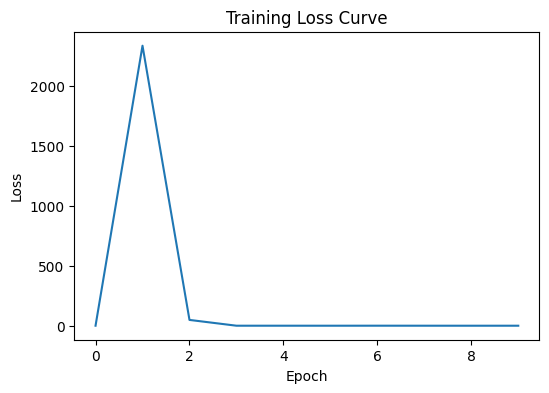

In [ ]:
model = SmallCNN(num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

epochs = 10
losses = []

for epoch in range(epochs):
    inputs = torch.randn(16, 3, 32, 32)
    targets = torch.randint(0, 10, (16,))

    outputs = model(inputs)
    loss = criterion(outputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f}")

# ---- Plot Loss ----
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 3. Observing CNN Training Behavior

Things to notice:

1. Loss decreases across iterations.
2. Gradients exist for:
    - Convolution weights
    - Fully connected weights
3. Convolution gradients accumulate over spatial locations.
4. Gradient magnitudes may differ across layers.

Important Insight:

CNN optimization is not fundamentally different from ANN.
The difference is in parameter structure, not learning rule.

## Concept-Check Questions

1) Why do we NOT apply softmax before CrossEntropyLoss in PyTorch?

2) If convolution is linear, why can CNN learn nonlinear decision boundaries?

3) Why does weight sharing mean fewer parameters?

4) If gradients in early layers are very small, what problem may occur?

5) Why might deeper CNNs be harder to train?

# Dropout Technique in CNN

## 1. Why Overfitting Happens (Even in CNN)

CNNs have fewer parameters than a fully-connected ANN on images,
but they can still overfit because:

- The model can memorize patterns specific to the training set.
- Fully connected layers (near the end) can become memorization-heavy.
- If dataset is small or labels are noisy, features can become overly specialized.

Overfitting signature:

- Training loss keeps decreasing
- Validation loss stops improving (or increases)

So we need regularization.
Dropout is one of the most effective regularizers.

## 2. Dropout Intuition

Dropout randomly "turns off" a fraction of activations during training.

If dropout probability is $p$:

- With probability $p$, a neuron output becomes 0
- With probability $1-p$, it stays active

This forces the network to avoid relying too much on any single neuron.

A simple view:

During training, we sample a mask:

$$
m \sim \text{Bernoulli}(1-p)
$$

and apply:

$$
\tilde{h} = m \odot h
$$

Key idea:
Dropout encourages redundancy and more robust representations.

## 3. Where Dropout is Applied in CNN

Typical placement:

- Strongest impact: before or between **Fully Connected layers**
- Optional: after convolution blocks (less common in small CNNs)

Most beginner-friendly rule:

Apply dropout after flatten or after first FC layer.

Important behavior:

- Dropout is ON during training
- Dropout is OFF during evaluation/testing

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

# CNN without Dropout
class CNN_NoDropout(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1   = nn.Linear(32*8*8, 64)
        self.fc2   = nn.Linear(64, num_classes)

    def forward(self, x):
        print("Input:", x.shape)
        x = self.conv1(x); print("conv1:", x.shape)
        x = F.relu(x);     print("relu1:", x.shape)
        x = self.pool(x);  print("pool1:", x.shape)

        x = self.conv2(x); print("conv2:", x.shape)
        x = F.relu(x);     print("relu2:", x.shape)
        x = self.pool(x);  print("pool2:", x.shape)

        x = torch.flatten(x, 1); print("flatten:", x.shape)
        x = self.fc1(x);         print("fc1:", x.shape)
        x = F.relu(x);           print("relu3:", x.shape)
        x = self.fc2(x);         print("logits:", x.shape)
        return x

# CNN with Dropout (applied after FC1 activation)
class CNN_WithDropout(nn.Module):
    def __init__(self, num_classes=10, p=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1   = nn.Linear(32*8*8, 64)
        self.drop  = nn.Dropout(p=p)
        self.fc2   = nn.Linear(64, num_classes)

    def forward(self, x):
        print("Input:", x.shape)
        x = self.conv1(x); print("conv1:", x.shape)
        x = F.relu(x);     print("relu1:", x.shape)
        x = self.pool(x);  print("pool1:", x.shape)

        x = self.conv2(x); print("conv2:", x.shape)
        x = F.relu(x);     print("relu2:", x.shape)
        x = self.pool(x);  print("pool2:", x.shape)

        x = torch.flatten(x, 1); print("flatten:", x.shape)
        x = self.fc1(x);         print("fc1:", x.shape)
        x = F.relu(x);           print("relu3:", x.shape)
        x = self.drop(x);        print("dropout:", x.shape)
        x = self.fc2(x);         print("logits:", x.shape)
        return x

# Dummy input
x = torch.randn(1, 3, 32, 32)

model_no = CNN_NoDropout()
model_do = CNN_WithDropout(p=0.5)

print("\n--- NO DROPOUT | eval() ---")
model_no.eval()
out_no = model_no(x)
print("Output sample (first 5 logits):", out_no[0, :5])

print("\n--- WITH DROPOUT | train() (dropout ON) ---")
model_do.train()
out_do_1 = model_do(x)
out_do_2 = model_do(x)
print("Output 1 (first 5 logits):", out_do_1[0, :5])
print("Output 2 (first 5 logits):", out_do_2[0, :5])
print("Are train-mode outputs identical?", torch.allclose(out_do_1, out_do_2))

print("\n--- WITH DROPOUT | eval() (dropout OFF) ---")
model_do.eval()
out_do_eval_1 = model_do(x)
out_do_eval_2 = model_do(x)
print("Eval Output 1 (first 5 logits):", out_do_eval_1[0, :5])
print("Eval Output 2 (first 5 logits):", out_do_eval_2[0, :5])
print("Are eval-mode outputs identical?", torch.allclose(out_do_eval_1, out_do_eval_2))


--- NO DROPOUT | eval() ---
Input: torch.Size([1, 3, 32, 32])
conv1: torch.Size([1, 16, 32, 32])
relu1: torch.Size([1, 16, 32, 32])
pool1: torch.Size([1, 16, 16, 16])
conv2: torch.Size([1, 32, 16, 16])
relu2: torch.Size([1, 32, 16, 16])
pool2: torch.Size([1, 32, 8, 8])
flatten: torch.Size([1, 2048])
fc1: torch.Size([1, 64])
relu3: torch.Size([1, 64])
logits: torch.Size([1, 10])
Output sample (first 5 logits): tensor([-0.0911,  0.1350, -0.2892,  0.2783,  0.0485], grad_fn=<SliceBackward0>)

--- WITH DROPOUT | train() (dropout ON) ---
Input: torch.Size([1, 3, 32, 32])
conv1: torch.Size([1, 16, 32, 32])
relu1: torch.Size([1, 16, 32, 32])
pool1: torch.Size([1, 16, 16, 16])
conv2: torch.Size([1, 32, 16, 16])
relu2: torch.Size([1, 32, 16, 16])
pool2: torch.Size([1, 32, 8, 8])
flatten: torch.Size([1, 2048])
fc1: torch.Size([1, 64])
relu3: torch.Size([1, 64])
dropout: torch.Size([1, 64])
logits: torch.Size([1, 10])
Input: torch.Size([1, 3, 32, 32])
conv1: torch.Size([1, 16, 32, 32])
relu1: tor

Input: torch.Size([32, 3, 32, 32])
conv1: torch.Size([32, 16, 32, 32])
relu1: torch.Size([32, 16, 32, 32])
pool1: torch.Size([32, 16, 16, 16])
conv2: torch.Size([32, 32, 16, 16])
relu2: torch.Size([32, 32, 16, 16])
pool2: torch.Size([32, 32, 8, 8])
flatten: torch.Size([32, 2048])
fc1: torch.Size([32, 64])
relu3: torch.Size([32, 64])
logits: torch.Size([32, 10])
Input: torch.Size([32, 3, 32, 32])
conv1: torch.Size([32, 16, 32, 32])
relu1: torch.Size([32, 16, 32, 32])
pool1: torch.Size([32, 16, 16, 16])
conv2: torch.Size([32, 32, 16, 16])
relu2: torch.Size([32, 32, 16, 16])
pool2: torch.Size([32, 32, 8, 8])
flatten: torch.Size([32, 2048])
fc1: torch.Size([32, 64])
relu3: torch.Size([32, 64])
logits: torch.Size([32, 10])
Input: torch.Size([32, 3, 32, 32])
conv1: torch.Size([32, 16, 32, 32])
relu1: torch.Size([32, 16, 32, 32])
pool1: torch.Size([32, 16, 16, 16])
conv2: torch.Size([32, 32, 16, 16])
relu2: torch.Size([32, 32, 16, 16])
pool2: torch.Size([32, 32, 8, 8])
flatten: torch.Size([32

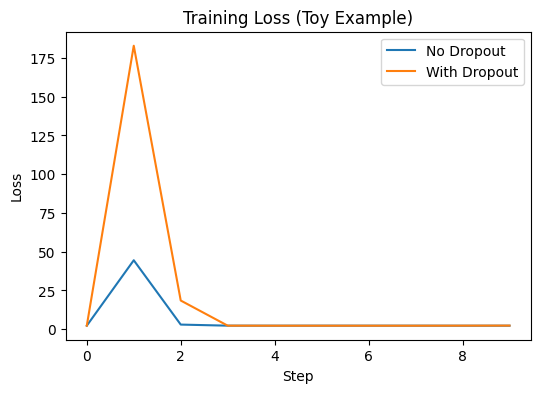

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(1)

def train_steps(model, steps=10, lr=0.05):
    model.train()
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    losses = []

    for _ in range(steps):
        inputs = torch.randn(32, 3, 32, 32)
        targets = torch.randint(0, 10, (32,))
        logits = model(inputs)
        loss = criterion(logits, targets)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())
    return losses

model_no = CNN_NoDropout()
model_do = CNN_WithDropout(p=0.5)

loss_no = train_steps(model_no, steps=10)
loss_do = train_steps(model_do, steps=10)

plt.figure(figsize=(6,4))
plt.plot(loss_no, label="No Dropout")
plt.plot(loss_do, label="With Dropout")
plt.title("Training Loss (Toy Example)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Concept-Check Questions

1) What exactly does Dropout randomize during training?

2) Why does Dropout reduce overfitting?

3) Why must Dropout be turned OFF during evaluation/testing?

4) Where is Dropout usually most effective in CNN classifiers?

5) If dropout probability $p$ increases, what happens to training difficulty?

# CNN vs ANN — Parameter Efficiency

## 1. Why Fully Connected ANN Struggles With Images

Consider an image:

$$
32 \times 32 \times 3
$$

Total pixels:

$$
32 \times 32 \times 3 = 3072
$$

If we flatten this and feed it to a fully connected layer with 1000 neurons:

$$
3072 \rightarrow 1000
$$

Number of parameters:

$$
3072 \times 1000 = 3,072,000
$$

Plus biases:

$$
+1000
$$

Total:

$$
3.07M \text{ parameters}
$$

This happens **in just one layer**.

ANN treats each pixel independently and ignores spatial structure.

## 2. CNN Parameter Structure

Consider a convolution layer:

- Input channels = 3
- Kernel size = 3×3
- Output channels = 32

Parameter count:

$$
\#params = C_{out}(C_{in}K^2 + 1)
$$

Substitute values:

$$
= 32(3 \times 3^2 + 1)
$$

$$
= 32(27 + 1)
$$

$$
= 896
$$

Compare:

ANN layer: **3,072,000 parameters**

CNN layer: **896 parameters**

This is the power of:

- Weight sharing
- Local connectivity

## 3. Spatial Inductive Bias

CNN assumes two important properties about images:

### Locality
Nearby pixels are related.

Example:
Edges, corners, textures.

### Translation invariance
The same pattern can appear anywhere in the image.

Example:
A cat ear in top-left or bottom-right is still a cat ear.

CNN encodes these assumptions through:

- Local convolution kernels
- Weight sharing across space

These assumptions are called an **inductive bias**.

Inductive bias helps the model generalize better with fewer parameters.

In [ ]:
import torch
import torch.nn as nn

# -----------------------------
# ANN Model
# -----------------------------

class SimpleANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3*32*32, 1000)
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):

        print("Input:", x.shape)

        x = self.flatten(x)
        print("Flatten:", x.shape)

        x = self.fc1(x)
        print("FC1:", x.shape)

        x = torch.relu(x)
        print("ReLU:", x.shape)

        x = self.fc2(x)
        print("Output:", x.shape)

        return x


# -----------------------------
# CNN Model
# -----------------------------

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc = nn.Linear(32*16*16, 10)

    def forward(self, x):

        print("Input:", x.shape)

        x = self.conv1(x)
        print("Conv1:", x.shape)

        x = torch.relu(x)
        print("ReLU:", x.shape)

        x = self.pool(x)
        print("Pool:", x.shape)

        x = torch.flatten(x, 1)
        print("Flatten:", x.shape)

        x = self.fc(x)
        print("Output:", x.shape)

        return x


# -----------------------------
# Parameter Counting Utility
# -----------------------------

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


ann = SimpleANN()
cnn = SimpleCNN()

print("\nANN parameters:", count_params(ann))
print("CNN parameters:", count_params(cnn))


# Dummy input
x = torch.randn(1,3,32,32)

print("\n---- ANN Forward ----")
ann(x)

print("\n---- CNN Forward ----")
cnn(x)


ANN parameters: 3083010
CNN parameters: 82826

---- ANN Forward ----
Input: torch.Size([1, 3, 32, 32])
Flatten: torch.Size([1, 3072])
FC1: torch.Size([1, 1000])
ReLU: torch.Size([1, 1000])
Output: torch.Size([1, 10])

---- CNN Forward ----
Input: torch.Size([1, 3, 32, 32])
Conv1: torch.Size([1, 32, 32, 32])
ReLU: torch.Size([1, 32, 32, 32])
Pool: torch.Size([1, 32, 16, 16])
Flatten: torch.Size([1, 8192])
Output: torch.Size([1, 10])


tensor([[ 0.8504,  0.7366,  0.1065, -0.0402, -0.6137, -0.1552,  0.2031,  0.0491,
          0.0278,  0.0941]], grad_fn=<AddmmBackward0>)

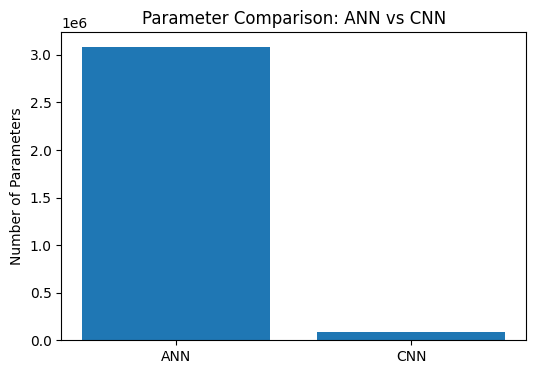

In [ ]:
import matplotlib.pyplot as plt

ann_params = count_params(ann)
cnn_params = count_params(cnn)

plt.figure(figsize=(6,4))

plt.bar(
    ["ANN", "CNN"],
    [ann_params, cnn_params]
)

plt.ylabel("Number of Parameters")
plt.title("Parameter Comparison: ANN vs CNN")

plt.show()

## Concept Check

1) Why does a fully connected ANN require many parameters for images?

2) Why does convolution not depend on image width and height for parameter count?

3) What property of CNN allows the same edge detector to work across the entire image?

4) What is meant by "spatial inductive bias"?

5) If we double image resolution, how does ANN parameter count change compared to CNN?

# AlexNet — The Breakthrough CNN

## 1. Before AlexNet (Pre-2012)

Before 2012, image recognition relied mostly on:

- Hand-crafted features
- Classical ML algorithms

Typical pipeline:

Image → Feature Extraction → Classifier

Examples of features:

- SIFT
- HOG
- SURF

These methods required **manual feature engineering**.

Deep learning existed, but training deep networks was difficult because:

- Networks were hard to optimize
- Activation functions saturated
- GPU training was uncommon
- Large labeled datasets were limited

## 2. The ImageNet Challenge

ImageNet is a large-scale image classification dataset.

Dataset scale:

- ~1.2 million training images
- 1000 object classes

Goal:

Given an image, predict the correct class.

Evaluation metric:

Top-5 error rate.

Before AlexNet (2011):

Best error rate ≈ 26%

After AlexNet (2012):

Error dropped to ≈ 15%

This was a massive improvement and shocked the vision community.

## 3. Key Innovations Introduced by AlexNet

AlexNet succeeded because of several engineering innovations.

### 1. ReLU Activation

Instead of sigmoid/tanh:

$$
ReLU(x) = \max(0, x)
$$

Benefits:

- Faster training
- Reduced vanishing gradient problem

---

### 2. Deep Architecture

AlexNet used **8 learnable layers**:

5 Convolution layers  
3 Fully connected layers

This depth allowed hierarchical feature learning.

---

### 3. GPU Training

AlexNet was trained on **two GPUs in parallel**.

This dramatically reduced training time.

---

### 4. Data Augmentation

Training images were augmented with:

- Random crops
- Horizontal flips
- Color variations

This improved generalization.

---

### 5. Dropout Regularization

Dropout was applied in the fully connected layers to reduce overfitting.

## 4. AlexNet Architecture (Conceptual)

Input image:

$$
227 \times 227 \times 3
$$

Layer structure:

Conv1 → ReLU → Pool  
Conv2 → ReLU → Pool  
Conv3 → ReLU  
Conv4 → ReLU  
Conv5 → ReLU → Pool  
Flatten  
FC1 → ReLU → Dropout  
FC2 → ReLU → Dropout  
FC3 → Softmax

The convolution layers progressively extract:

Edges → Textures → Object parts → Object concepts

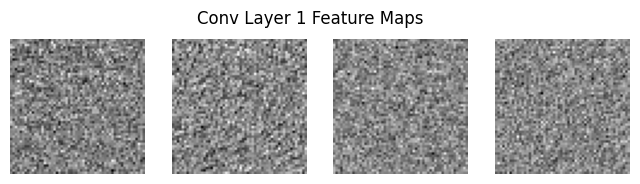

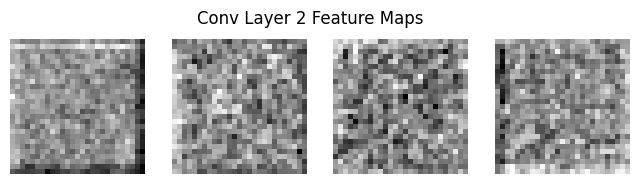

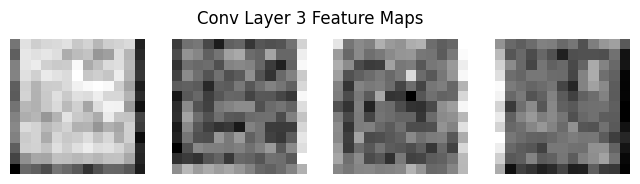

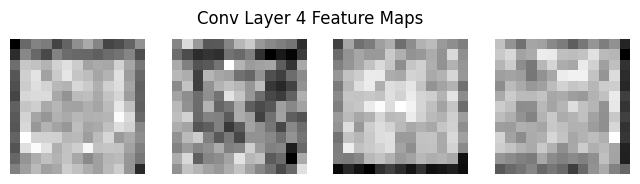

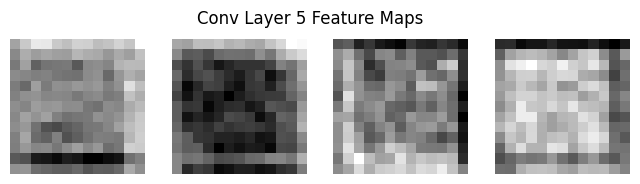

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Simplified AlexNet-like feature extractor
class MiniAlexNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(3,2),

            nn.Conv2d(64,192,5,padding=2),
            nn.ReLU(),
            nn.MaxPool2d(3,2),

            nn.Conv2d(192,384,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(384,256,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(3,2)
        )

    def forward(self,x):

        activations = []

        for layer in self.features:

            x = layer(x)

            if isinstance(layer, nn.Conv2d):
                activations.append(x)

        return activations


model = MiniAlexNet()

x = torch.randn(1,3,227,227)

activations = model(x)

# visualize first 4 channels from each conv layer
for i,act in enumerate(activations):

    act = act.detach()

    plt.figure(figsize=(8,2))

    for j in range(4):

        plt.subplot(1,4,j+1)

        img = act[0,j]

        img = (img-img.min())/(img.max()-img.min()+1e-5)

        plt.imshow(img,cmap='gray')

        plt.axis("off")

    plt.suptitle(f"Conv Layer {i+1} Feature Maps")

    plt.show()

## 5. Why AlexNet Was Revolutionary

AlexNet demonstrated that:

Deep CNN + large dataset + GPU training
can outperform traditional computer vision methods.

This triggered the modern deep learning revolution.

After AlexNet:

- VGGNet (2014)
- GoogLeNet (2014)
- ResNet (2015)

CNN became the dominant architecture for vision tasks.

## Concept Check

1) What major limitation did pre-2012 computer vision systems have?

2) Why did ReLU significantly improve deep network training?

3) Why was GPU training essential for AlexNet?

4) Why did AlexNet use dropout in fully connected layers?

5) What is meant by hierarchical feature learning?

# Conceptual Closure — Understanding CNNs

## 1. The Core Idea of CNN

A Convolutional Neural Network is fundamentally a sequence of:

Structured Linear Operations + Nonlinearities

Mathematically:

$$
x \rightarrow Conv \rightarrow ReLU \rightarrow Pool \rightarrow Conv \rightarrow ... \rightarrow FC
$$

Each convolution layer learns filters that detect spatial patterns.

Examples:

- Edges
- Corners
- Textures
- Object parts

These learned filters allow the network to automatically extract features from raw images.

## 2. Hierarchical Feature Learning

CNNs learn representations hierarchically.

Early layers learn simple patterns.

Examples:

Edges  
Gradients  
Color contrasts  

Middle layers learn combinations of edges.

Examples:

Textures  
Shapes  
Corners  

Deeper layers learn semantic concepts.

Examples:

Eyes  
Wheels  
Faces  

Final layers combine these features to identify objects.

This hierarchy allows CNNs to move from **low-level signals to high-level concepts**.

## 3. CNN as Structured Linear Transformations

Recall ANN:

$$
y = Wx + b
$$

CNN performs a similar linear transformation, but with constraints.

Convolution introduces two important structures:

Local Connectivity

Each neuron sees only a small spatial region.

Weight Sharing

The same filter is reused across the entire image.

This reduces parameter count and improves generalization.

So CNN layers are essentially **structured versions of linear layers**.

## 4. Why CNNs Generalize Well

CNNs generalize better than fully connected networks on images because they encode important assumptions about visual data.

These assumptions are called **inductive biases**.

Important CNN inductive biases:

Locality  
Nearby pixels are related.

Translation Invariance  
The same object can appear anywhere in the image.

Parameter Sharing  
The same feature detector is reused across the image.

These biases allow CNNs to learn meaningful representations using fewer parameters.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class HierarchyCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

    def forward(self,x):

        shapes = []

        x = self.conv1(x)
        shapes.append(x.shape)

        x = torch.relu(x)
        x = self.pool(x)
        shapes.append(x.shape)

        x = self.conv2(x)
        shapes.append(x.shape)

        x = torch.relu(x)
        x = self.pool(x)
        shapes.append(x.shape)

        x = self.conv3(x)
        shapes.append(x.shape)

        return shapes


model = HierarchyCNN()

x = torch.randn(1,3,32,32)

shapes = model(x)

print("Feature hierarchy through CNN:\n")

for i,s in enumerate(shapes):

    print(f"Layer {i+1}:",s)

Feature hierarchy through CNN:

Layer 1: torch.Size([1, 16, 32, 32])
Layer 2: torch.Size([1, 16, 16, 16])
Layer 3: torch.Size([1, 32, 16, 16])
Layer 4: torch.Size([1, 32, 8, 8])
Layer 5: torch.Size([1, 64, 8, 8])


## 5. Mental Model of CNN

Think of a CNN as a pipeline:

Image

↓

Edge detectors

↓

Texture detectors

↓

Part detectors

↓

Object detectors

↓

Classifier

This is why CNNs work well for vision tasks.

## Concept Check

1) Why do CNNs learn hierarchical features?

2) What does weight sharing achieve?

3) Why does spatial resolution decrease across layers?

4) Why do deeper layers usually have more channels?

5) What problem would occur if CNN used fully connected layers from the start?